In [2]:
import pandas as pd
from src.processing import find_pareto_front
from src.visualization import display_pareto_front, display_two_pareto_fronts, display_fitness_landscape_with_2pareto#, plot_gamma_distances_distribution
from src.metrics import calculate_gamma_convergence_metric, print_gamma_metric

In [3]:
df = pd.read_parquet('data/df_surrogate.parquet')
df_pareto_real = pd.read_parquet('data/pareto_df3.parquet')

print(df.shape)
print(df.columns)
df.head()

(1000000, 46)
Index(['registro', 'fitness1_eq0', 'fitness1_eq1', 'fitness1_eq2',
       'fitness1_eq3', 'fitness1_eq4', 'fitness1_eq5', 'fitness1_eq6',
       'fitness1_eq7', 'fitness1_eq8', 'fitness1_eq9', 'fitness2_eq0',
       'fitness2_eq1', 'fitness2_eq2', 'fitness2_eq3', 'fitness2_eq4',
       'fitness2_eq5', 'fitness2_eq6', 'fitness2_eq7', 'fitness2_eq8',
       'fitness2_eq9', 'fitness2_eq10', 'fitness2_eq11', 'fitness1',
       'fitness2', 'fitness_full', 'regiao', 'fronteira_verdadeira',
       'fitness1_c1', 'fitness1_c2', 'fitness1_c3', 'erro1_c1', 'erro_abs1_c1',
       'erro1_c2', 'erro_abs1_c2', 'erro1_c3', 'erro_abs1_c3', 'fitness2_c1',
       'fitness2_c2', 'fitness2_c3', 'erro2_c1', 'erro_abs2_c1', 'erro2_c2',
       'erro_abs2_c2', 'erro2_c3', 'erro_abs2_c3'],
      dtype='object')


,registro,fitness1_eq0,fitness1_eq1,fitness1_eq2,fitness1_eq3,fitness1_eq4,fitness1_eq5,fitness1_eq6,fitness1_eq7,fitness1_eq8,...,erro_abs1_c3,fitness2_c1,fitness2_c2,fitness2_c3,erro2_c1,erro_abs2_c1,erro2_c2,erro_abs2_c2,erro2_c3,erro_abs2_c3
0,0,0.000000,1.0,0.00000,0.000000,0.00000,0.000000,0.0000,2.67401,0.162091,...,0.044322,3.177411,3.089214,3.283747,0.199269,0.199269,0.287465,0.287465,0.092933,0.092933
1,1,0.000007,1.0,0.00004,0.000025,0.00005,0.000075,0.0001,2.67401,0.161838,...,0.044387,3.177411,3.089214,3.283747,0.199369,0.199369,0.287566,0.287566,0.093034,0.093034
2,2,0.000015,1.0,0.00008,0.000050,0.00010,0.000150,0.0002,2.67401,0.161585,...,0.044452,3.177411,3.089214,3.283747,0.199470,0.199470,0.287667,0.287667,0.093134,0.093134
3,3,0.000022,1.0,0.00012,0.000075,0.00015,0.000225,0.0003,2.67401,0.161333,...,0.044517,3.177411,3.089214,3.283747,0.199570,0.199570,0.287767,0.287767,0.093235,0.093235
4,4,0.000030,1.0,0.00016,0.000100,0.00020,0.000300,0.0004,2.67401,0.161080,...,0.044581,3.177411,3.089214,3.283747,0.199671,0.199671,0.287868,0.287868,0.093335,0.093335


## 1. Força bruta

Encontrando fronteira de Pareto (algoritmo otimizado)...
Total de pontos no espaço de busca: 1,000,000
✅ Fronteira de Pareto encontrada!
Fronteira de Pareto contém 318 pontos.
Isso representa 0.0318% do espaço de busca.


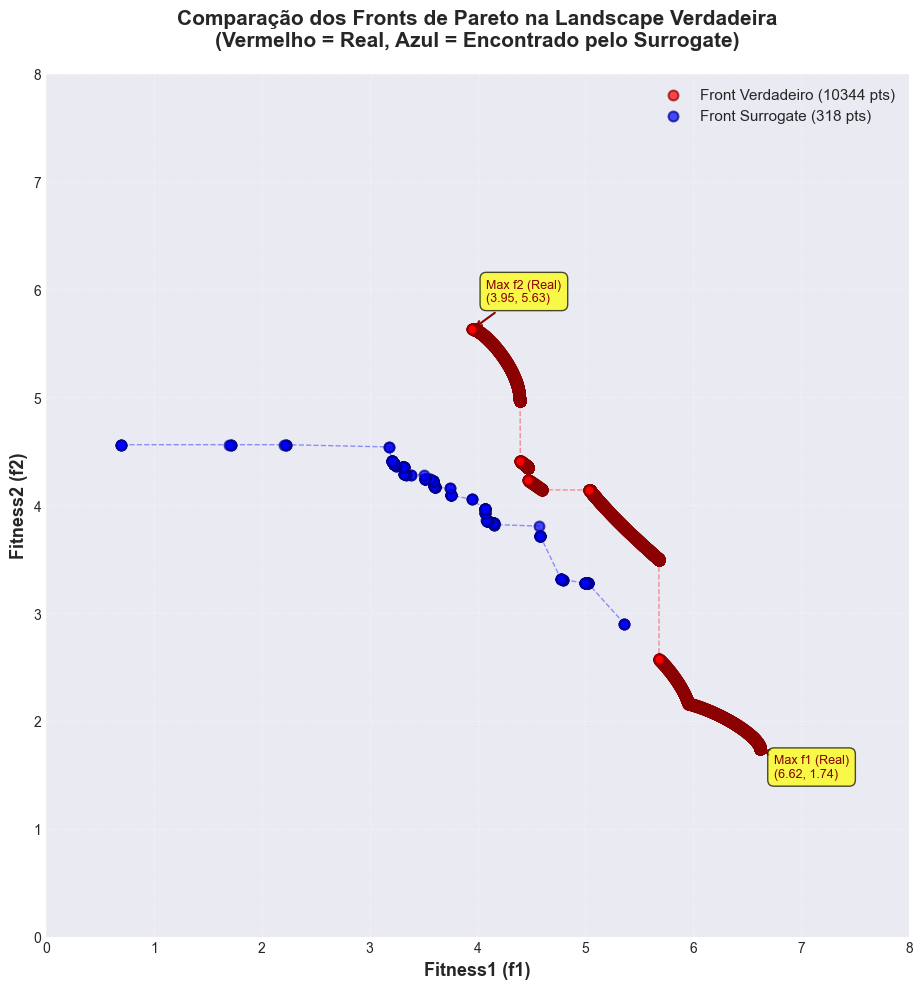


✅ Visualização concluída!


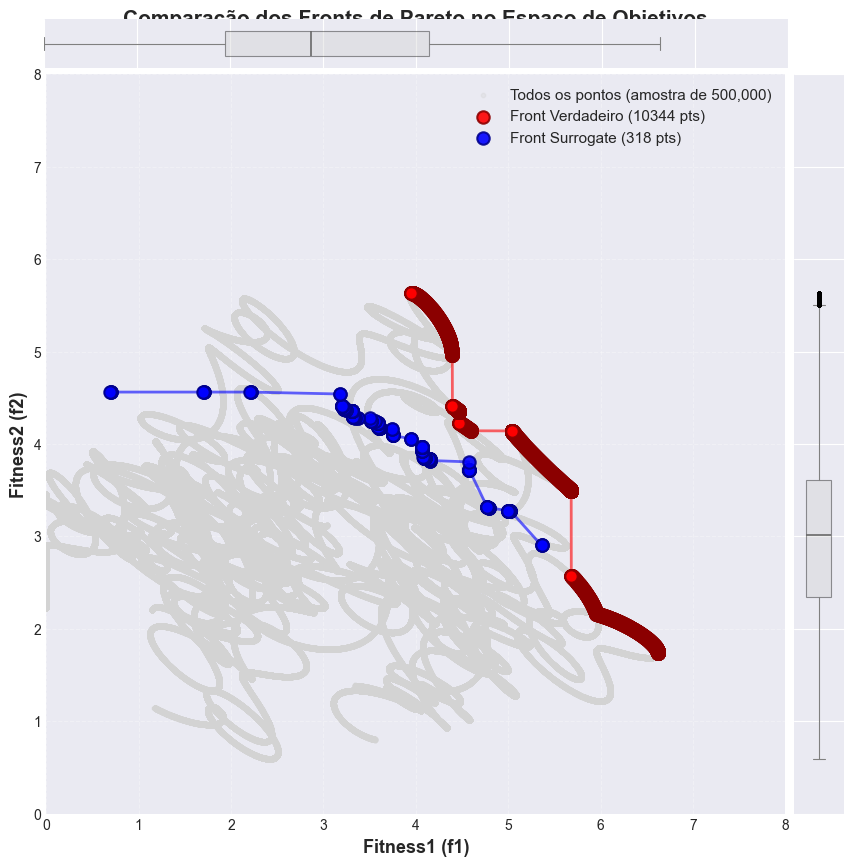

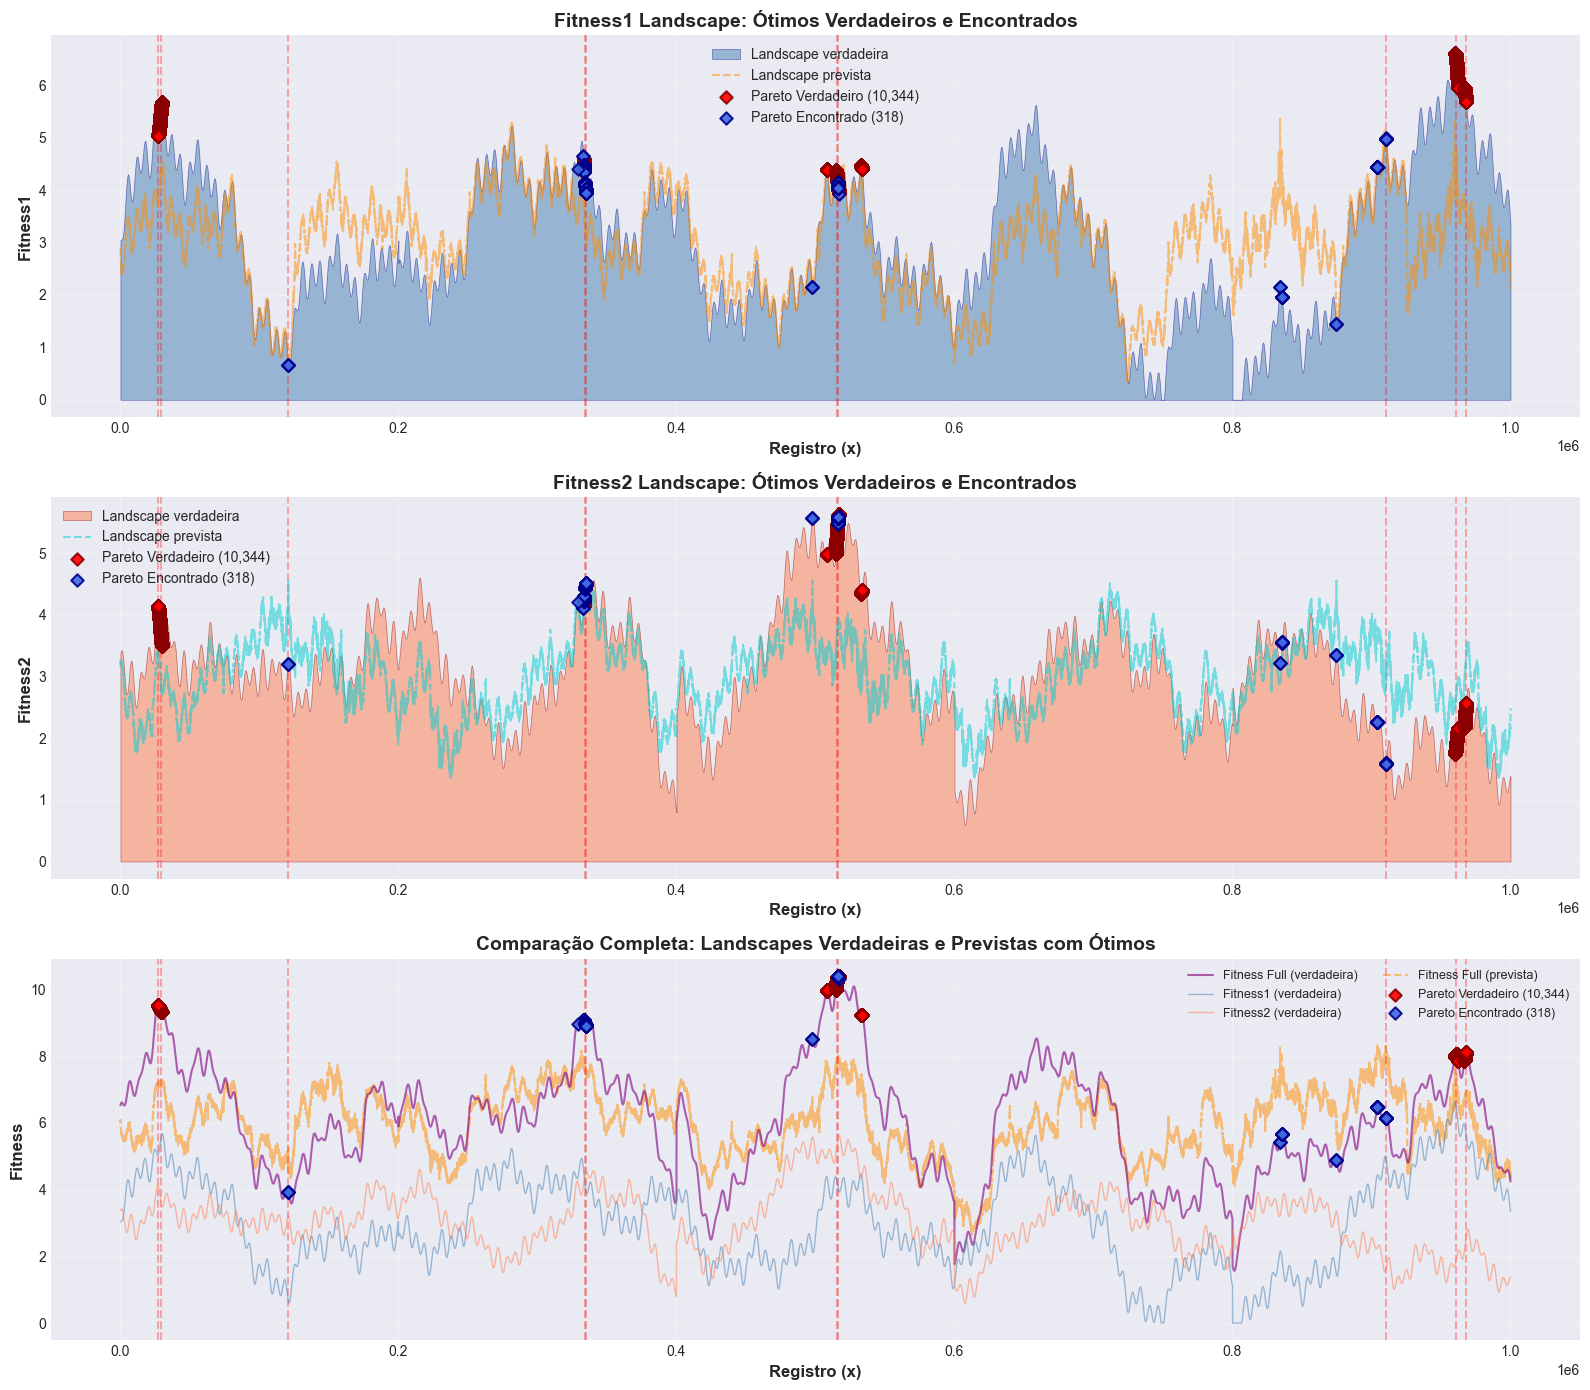

In [4]:
df_predicted = df.copy().drop(columns=['fitness1', 'fitness2'])
df_predicted.rename(columns={'fitness1_c1': 'fitness1', 'fitness2_c1': 'fitness2'}, inplace=True)
df_pareto_surrogate = find_pareto_front(df_predicted)

display_two_pareto_fronts(df, df_pareto_real, df_pareto_surrogate)
display_fitness_landscape_with_2pareto(df, df_pareto_real, df_pareto_surrogate)

## 2. Métrica de Convergência (Gamma)


In [5]:
# Calcular a métrica gamma
gamma_results = calculate_gamma_convergence_metric(df, df_pareto_real, df_pareto_surrogate)

# Imprimir resultados formatados
print_gamma_metric(gamma_results)


MÉTRICA DE CONVERGÊNCIA GAMMA (γ)

📊 Informações dos Fronts:
   • Pontos no front verdadeiro: 10,344
   • Pontos no front encontrado: 318

🎯 Métrica de Convergência:
   • Gamma (γ) - Média:        0.898084
   • Desvio Padrão:            0.449989

📈 Estatísticas das Distâncias Mínimas:
   • Mínima:                   0.336506
   • Máxima:                   3.432191
   • Mediana:                  0.831093

💡 Interpretação:
   ✅ EXCELENTE convergência (γ < 1.0)

   Quanto menor o valor de γ, melhor a convergência.
   γ = 0 indica que todas as soluções estão exatamente no front real.


In [7]:
gamma_results

{'gamma_mean': 0.8980837443752174,
 'gamma_std': 0.4499890529642327,
 'min_distances': array([0.46007115, 0.46007115, 0.46007115, 0.60533568, 0.60533568,
        0.60533568, 0.60533568, 0.60533568, 0.60533568, 0.60533568,
        0.60533568, 0.60533568, 0.60533568, 0.61194759, 0.62500534,
        0.62500534, 0.62500534, 0.62500534, 0.62500534, 0.62500534,
        0.62500534, 0.62500534, 0.7456012 , 0.7456012 , 0.7456012 ,
        0.7456012 , 0.75304738, 0.75304738, 0.75304738, 0.75304738,
        0.75304738, 0.75304738, 0.75304738, 0.4238377 , 0.42355532,
        0.42355532, 0.42355532, 0.42355532, 0.42355532, 0.42355532,
        0.42355532, 0.42355532, 0.42355532, 0.42355532, 0.42355532,
        0.42355532, 0.33650587, 0.51677307, 0.51677307, 0.51677307,
        0.50771751, 0.50771751, 0.50771751, 0.50771751, 0.50771751,
        0.51175893, 0.51175893, 0.51175893, 0.51175893, 0.51175893,
        0.51175893, 0.51175893, 0.51175893, 0.51175893, 0.51175893,
        0.51175893, 0.51175893